# 🏏 15 Years of IPL: What Makes Teams Successful?

## Objective

The goal of this project is to analyze 15 years of IPL data and identify the factors that contribute to team success. The analysis explores team performance, winning patterns, toss impact, player contributions, and scoring trends to uncover meaningful insights.

# IPL Data Analysis: Team Dominance, Toss Impact, Batting Evolution & Match Insights

## Business Problem

The Indian Premier League (IPL) is one of the world's most competitive T20 cricket leagues. This project analyzes historical IPL data to identify the factors behind team success, batting performance, venue influence, and match outcomes.

## Objectives

1. Identify the most successful IPL teams.
2. Analyze the impact of winning the toss.
3. Study batting evolution across seasons.
4. Find the greatest IPL performers.
5. Analyze venue influence on scoring.
6. Discover the most thrilling IPL matches.

In [227]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
deliveries = pd.read_csv('deliveries.csv')
matches = pd.read_csv('matches.csv')



In [228]:
deliveries.shape
deliveries.info()
deliveries.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [229]:

matches.shape
matches.info()
matches.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [230]:
matches.isnull().sum().sort_values(ascending= False)

,0
method,1074
city,51
result_margin,19
player_of_match,5
winner,5
target_runs,3
target_overs,3
id,0
date,0
season,0


In [231]:
deliveries.isnull().sum().sort_values(ascending=False)

,0
fielder,251566
dismissal_kind,247970
player_dismissed,247970
extras_type,246795
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
non_striker,0


In [232]:
sorted(matches['team1'].unique())
sorted(matches['team2'].unique())
sorted(matches['winner'].dropna().unique())

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Delhi Daredevils',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kings XI Punjab',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiant',
 'Rising Pune Supergiants',
 'Royal Challengers Bangalore',
 'Royal Challengers Bengaluru',
 'Sunrisers Hyderabad']

In [233]:
team_rename = {
    'Delhi Daredevils' : 'Delhi Capitals',
    'Kings XI Punjab' : 'Punjab Kings',
    'Rising Pune Supergiant' : 'Rising Pune Supergiants',
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru'


}

matches['team1'] = matches['team1'].replace(team_rename)
matches['team2'] = matches['team2'].replace(team_rename)
matches['winner'] = matches['winner'].replace(team_rename)
matches['toss_winner'] = matches['toss_winner'].replace(team_rename)
deliveries['batting_team'] = deliveries['batting_team'].replace(team_rename)






In [234]:
sorted(matches['team1'].unique())

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiants',
 'Royal Challengers Bengaluru',
 'Sunrisers Hyderabad']

#  Team Dominance Analysis

This section analyzes the overall performance of IPL teams based on matches played, total wins, win percentage, and consistency across seasons.

In [235]:
total_matches = matches['team1'].value_counts() + matches['team2'].value_counts()
matches_played = total_matches.reset_index()
matches_played.columns = ['Team', 'Matches_Played']
matches_played.head(10)

,Team,Matches_Played
0,Chennai Super Kings,238
1,Deccan Chargers,75
2,Delhi Capitals,252
3,Gujarat Lions,30
4,Gujarat Titans,45
5,Kochi Tuskers Kerala,14
6,Kolkata Knight Riders,251
7,Lucknow Super Giants,44
8,Mumbai Indians,261
9,Pune Warriors,46


In [236]:
# Most Sucessfull Team

wins = matches['winner'].value_counts().reset_index()
wins.columns = ['Team','Wins']
wins.head(10)

,Team,Wins
0,Mumbai Indians,144
1,Chennai Super Kings,138
2,Kolkata Knight Riders,131
3,Royal Challengers Bengaluru,123
4,Delhi Capitals,115
5,Punjab Kings,112
6,Rajasthan Royals,112
7,Sunrisers Hyderabad,88
8,Deccan Chargers,29
9,Gujarat Titans,28


In [237]:
team_stats = pd.merge(matches_played, wins, on = 'Team' )
team_stats.head(10)

,Team,Matches_Played,Wins
0,Chennai Super Kings,238,138
1,Deccan Chargers,75,29
2,Delhi Capitals,252,115
3,Gujarat Lions,30,13
4,Gujarat Titans,45,28
5,Kochi Tuskers Kerala,14,6
6,Kolkata Knight Riders,251,131
7,Lucknow Super Giants,44,24
8,Mumbai Indians,261,144
9,Pune Warriors,46,12


In [238]:
team_stats['Win_Percentage'] = (
    team_stats['Wins'] / team_stats['Matches_Played']
) * 100

team_stats.head(10)

,Team,Matches_Played,Wins,Win_Percentage
0,Chennai Super Kings,238,138,57.983193
1,Deccan Chargers,75,29,38.666667
2,Delhi Capitals,252,115,45.634921
3,Gujarat Lions,30,13,43.333333
4,Gujarat Titans,45,28,62.222222
5,Kochi Tuskers Kerala,14,6,42.857143
6,Kolkata Knight Riders,251,131,52.191235
7,Lucknow Super Giants,44,24,54.545455
8,Mumbai Indians,261,144,55.172414
9,Pune Warriors,46,12,26.086957


In [239]:
team_stats.sort_values(
    by='Win_Percentage',
    ascending=False
).head(10)

,Team,Matches_Played,Wins,Win_Percentage
4,Gujarat Titans,45,28,62.222222
0,Chennai Super Kings,238,138,57.983193
8,Mumbai Indians,261,144,55.172414
7,Lucknow Super Giants,44,24,54.545455
6,Kolkata Knight Riders,251,131,52.191235
11,Rajasthan Royals,221,112,50.678733
12,Rising Pune Supergiants,30,15,50.000000
14,Sunrisers Hyderabad,182,88,48.351648
13,Royal Challengers Bengaluru,255,123,48.235294
2,Delhi Capitals,252,115,45.634921


### Key Insight

Gujarat Titans have the highest win percentage (62.22%) among all IPL teams. However, they have played only 45 matches, which is significantly fewer than long-established franchises.

Among teams with over 200 matches played, Chennai Super Kings (57.98%) and Mumbai Indians (55.17%) have demonstrated the strongest long-term consistency and success.

In [240]:
matches.groupby('season')['id'].count()

,id
season,
2007/08,58
2009,57
2009/10,60
2011,73
2012,74
2013,76
2014,60
2015,59
2016,60


In [241]:
matches.groupby(['season', 'winner'])['id'].count()

season   winner                     
2007/08  Chennai Super Kings            9
         Deccan Chargers                2
         Delhi Capitals                 7
         Kolkata Knight Riders          6
         Mumbai Indians                 7
                                       ..
2024     Mumbai Indians                 4
         Punjab Kings                   5
         Rajasthan Royals               9
         Royal Challengers Bengaluru    7
         Sunrisers Hyderabad            9
Name: id, Length: 146, dtype: int64

In [242]:
season_wins = matches.groupby(['season','winner'])['id'].count().reset_index()

season_wins.columns = ['Season', 'Team','Wins' ]
season_wins.head(10)

,Season,Team,Wins
0,2007/08,Chennai Super Kings,9
1,2007/08,Deccan Chargers,2
2,2007/08,Delhi Capitals,7
3,2007/08,Kolkata Knight Riders,6
4,2007/08,Mumbai Indians,7
5,2007/08,Punjab Kings,10
6,2007/08,Rajasthan Royals,13
7,2007/08,Royal Challengers Bengaluru,4
8,2009,Chennai Super Kings,8
9,2009,Deccan Chargers,9


In [243]:
season_wins[season_wins['Team']==  'Chennai Super Kings']

,Season,Team,Wins
0,2007/08,Chennai Super Kings,9
8,2009,Chennai Super Kings,8
16,2009/10,Chennai Super Kings,9
24,2011,Chennai Super Kings,11
34,2012,Chennai Super Kings,10
43,2013,Chennai Super Kings,12
52,2014,Chennai Super Kings,10
60,2015,Chennai Super Kings,10
84,2018,Chennai Super Kings,11
92,2019,Chennai Super Kings,10


In [244]:
season_wins.groupby('Team')['Wins'].mean().sort_values(ascending=False)

,Wins
Team,
Gujarat Titans,9.333333
Chennai Super Kings,9.200000
Mumbai Indians,8.470588
Lucknow Super Giants,8.000000
Kolkata Knight Riders,7.705882
Rising Pune Supergiants,7.500000
Rajasthan Royals,7.466667
Sunrisers Hyderabad,7.333333
Royal Challengers Bengaluru,7.235294


In [245]:
import os

os.makedirs('Images', exist_ok=True)

## Team Win Percentage

Win percentage provides a fair comparison between teams by accounting for the number of matches played.

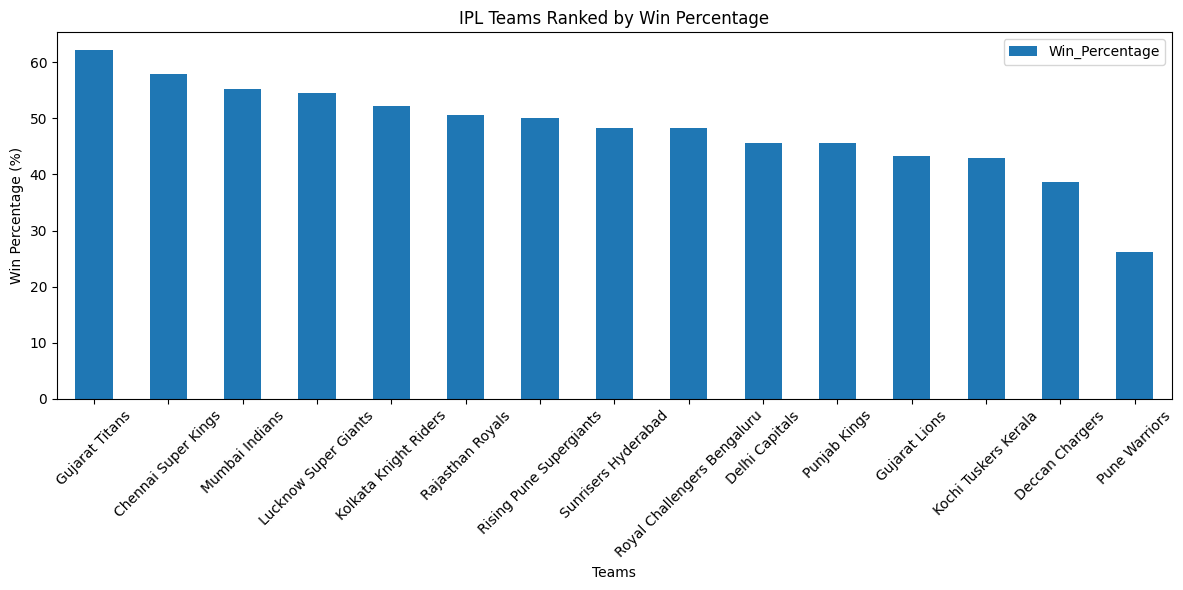

In [246]:


team_stats.sort_values(
    by='Win_Percentage',
    ascending=False
).plot(
    x='Team',
    y='Win_Percentage',
    kind='bar',
    figsize=(12,6)
)

plt.title('IPL Teams Ranked by Win Percentage')
plt.xlabel('Teams')
plt.ylabel('Win Percentage (%)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('Images/team_win_percentage.png', dpi=300, bbox_inches = 'tight')

plt.show()

### Key Insight

- Gujarat Titans recorded the highest win percentage (62.22%).
- However, they have participated in significantly fewer matches than long-established franchises.
- Chennai Super Kings (57.98%) and Mumbai Indians (55.17%) have maintained elite win rates across more than 200 matches, demonstrating sustained excellence.

# Does Winning the Toss Actually Matter?

A common belief in cricket is that winning the toss provides a significant advantage. This section investigates whether toss winners actually win matches more often.

In [247]:
(matches['toss_winner'] == matches['winner']).sum()

np.int64(554)

In [248]:
toss_match_win_pct =(
    (matches['toss_winner'] == matches['winner']).sum()
    / len(matches)
) * 100

toss_match_win_pct

np.float64(50.593607305936075)

## Toss Winner vs Match Winner

A common belief among cricket fans is that winning the toss provides a significant advantage.

However, analysis of IPL matches shows that teams winning the toss also won the match only 50.6% of the time.

This suggests that winning the toss alone does not significantly influence match outcomes, and team performance remains the primary determinant of success.

In [249]:
matches['toss_decision'].value_counts()

,count
toss_decision,
field,704
bat,391


In [250]:
bat_wins = matches[
    (matches['toss_decision'] == 'bat') &
    (matches['toss_winner']== matches['winner'])
].shape[0]

field_wins = matches[
    (matches['toss_decision'] == 'field') &
    (matches['toss_winner']== matches['winner'])

].shape[0]

print("Bat decision wins:", bat_wins)
print("Field decision wins:", field_wins)




Bat decision wins: 177
Field decision wins: 377


In [251]:
bat_total = (matches['toss_decision']== 'bat').sum()
field_total = (matches['toss_decision'] == 'field').sum()

bat_win_pct = (bat_wins / bat_total)* 100
field_win_pct = (field_wins / field_total)* 100

print("Bat First Success Rate:", round(bat_win_pct,2), "%")
print("Field First Success Rate:", round(field_win_pct,2), "%")

Bat First Success Rate: 45.27 %
Field First Success Rate: 53.55 %


## Toss Impact Analysis

One of the most debated topics in cricket is whether winning the toss provides a significant advantage.

Analysis of IPL matches shows:

- Teams choosing to field first won 53.55% of matches.
- Teams choosing to bat first won 45.27% of matches.
- Captains preferred to field first in over 64% of matches.

### Key Insight

The data supports the popular belief that chasing offers a slight competitive advantage in IPL matches.

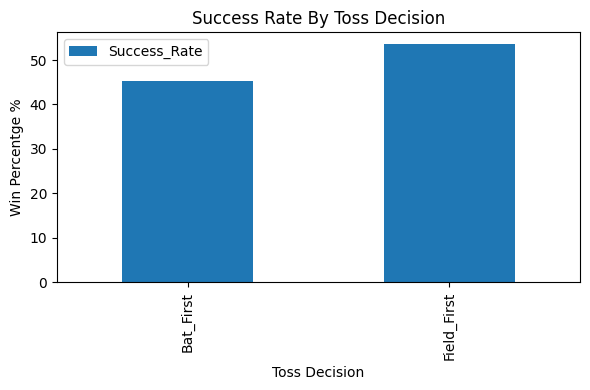

In [252]:
toss_results = pd.DataFrame({
    'Decision':['Bat_First', 'Field_First'],
    'Success_Rate': [bat_win_pct, field_win_pct]

})

toss_results.plot(
    x = 'Decision',
    y = 'Success_Rate',
    kind = 'bar',
    figsize =(6,4)
)
plt.title('Success Rate By Toss Decision')
plt.xlabel("Toss Decision")
plt.ylabel('Win Percentge %')
plt.tight_layout()

plt.savefig('Images/toss_impact.png', dpi=300, bbox_inches='tight')

plt.show()

## IPL Batting Evolution

Cricket has changed significantly since the first IPL season.

This analysis investigates whether scoring patterns have increased over time, indicating a shift toward a more batting-friendly tournament.


- Has the average team score increased over the years?
- Are teams scoring more aggressively in recent seasons?
- Has IPL become a batting-dominated competition?

In [253]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [254]:
team_scores = deliveries.groupby(['match_id','inning']) ['total_runs'].sum().reset_index()
team_scores.head()

,match_id,inning,total_runs
0,335982,1,222
1,335982,2,82
2,335983,1,240
3,335983,2,207
4,335984,1,129


In [255]:
team_scores = pd.merge(team_scores, matches[['id','season']],left_on = 'match_id', right_on='id')
team_scores.drop('id', axis = 1,inplace = True)
team_scores.head()

,match_id,inning,total_runs,season
0,335982,1,222,2007/08
1,335982,2,82,2007/08
2,335983,1,240,2007/08
3,335983,2,207,2007/08
4,335984,1,129,2007/08


In [256]:
avg_score_by_season = team_scores.groupby('season')['total_runs'].mean().round(2)
avg_score_by_season

,total_runs
season,
2007/08,154.63
2009,140.97
2009/10,154.78
2011,145.89
2012,151.71
2013,144.88
2014,155.17
2015,154.23
2016,157.18


In [257]:
avg_score_by_season = avg_score_by_season.reset_index()
avg_score_by_season.head(10)


,season,total_runs
0,2007/08,154.63
1,2009,140.97
2,2009/10,154.78
3,2011,145.89
4,2012,151.71
5,2013,144.88
6,2014,155.17
7,2015,154.23
8,2016,157.18
9,2017,156.55


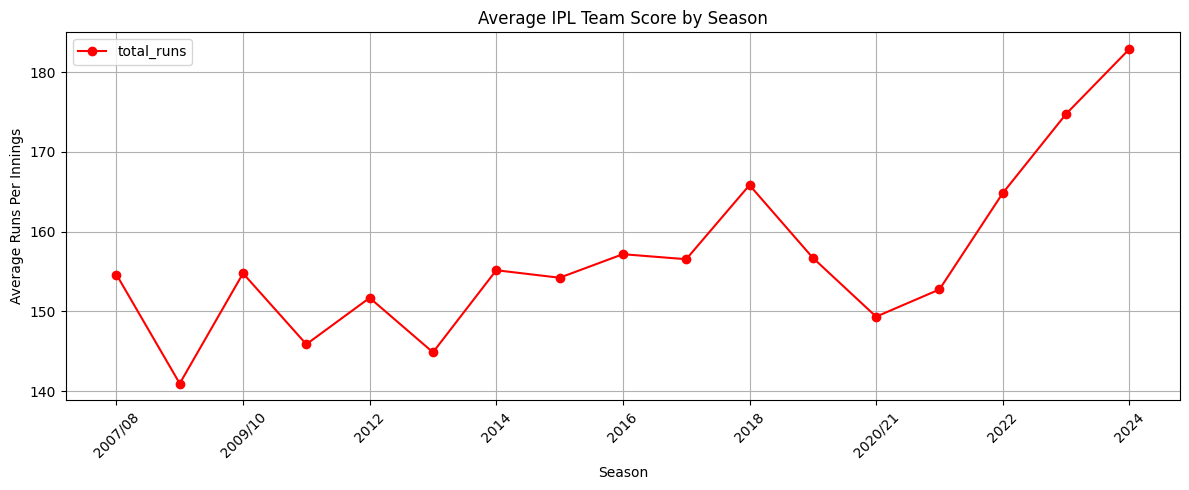

In [258]:
avg_score_by_season.plot(
    x='season',
    y='total_runs',
    kind='line',
    figsize=(12,5),
    marker ='o',
    color= 'red'

)

plt.title('Average IPL Team Score by Season')
plt.xlabel('Season')
plt.ylabel('Average Runs Per Innings')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()

plt.savefig('Images/avg_team_score_by_season.png', dpi = 500, bbox_inches ='tight' )
plt.show()


### Average Team Score by IPL Season

The average innings score was calculated for each IPL season to understand how scoring patterns have evolved over time.

This analysis helps identify whether the IPL has become more batting-friendly and whether teams are consistently posting higher totals in recent years.

### Key Insight

Average team scores have generally increased over the history of the IPL.

While scoring fluctuated between seasons, a strong upward trend is visible from 2022 onwards.

The 2024 season recorded the highest average innings score in IPL history, indicating a highly batting-friendly era driven by aggressive batting strategies, improved player skill levels, and modern T20 tactics.

In [259]:
team_avg_score = deliveries.groupby('batting_team')['total_runs'].sum()

innings_count = deliveries.groupby(['match_id','inning','batting_team'])['total_runs'].sum().reset_index()

team_inning = innings_count.groupby('batting_team').size()

team_avg_score = (
    team_avg_score / team_inning
).sort_values(ascending=False)

team_avg_score.head(10)


,0
batting_team,
Gujarat Titans,172.377778
Lucknow Super Giants,170.681818
Chennai Super Kings,162.306723
Mumbai Indians,158.556391
Punjab Kings,157.768924
Royal Challengers Bengaluru,157.449612
Gujarat Lions,156.838710
Sunrisers Hyderabad,156.295699
Rajasthan Royals,155.816143


### Top 10 IPL Teams by Average Score

This visualization compares the average runs scored per innings by the top-performing IPL teams.

Average score is calculated by dividing total runs scored by total innings played, providing a fair comparison across teams with different numbers of matches.

Higher average scores indicate stronger batting performances and greater scoring consistency.

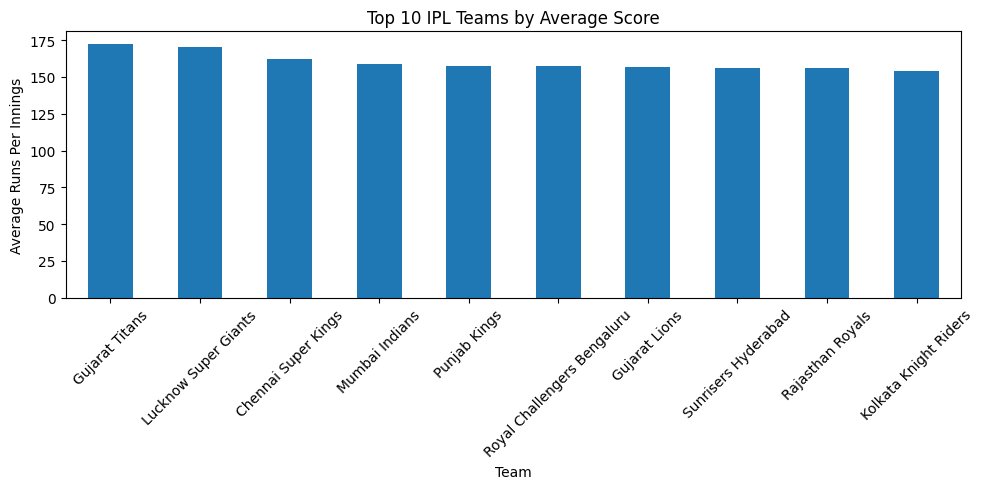

In [260]:
team_avg_score.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 IPL Teams by Average Score')
plt.xlabel('Team')
plt.ylabel('Average Runs Per Innings')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    'Images/top_10_team_avg_score.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Insight

Royal Challengers Bengaluru recorded the highest average innings score among IPL teams.

Newer franchises such as Gujarat Titans and Lucknow Super Giants also rank highly, reflecting the modern high-scoring nature of the IPL.

Traditional teams like Chennai Super Kings and Mumbai Indians remain among the strongest batting sides while maintaining performance over a much larger number of innings.

### Highest Team Totals in IPL History



In [261]:
highest_scores = deliveries.groupby(['match_id','inning', 'batting_team'])['total_runs'].sum().reset_index()
highest_scores.sort_values(by ='total_runs',ascending = False).head(10)

,match_id,inning,batting_team,total_runs
2133,1426268,1,Sunrisers Hyderabad,287
2089,1422126,1,Sunrisers Hyderabad,277
2105,1422134,1,Kolkata Knight Riders,272
2143,1426273,1,Sunrisers Hyderabad,266
709,598027,1,Royal Challengers Bengaluru,263
2134,1426268,2,Royal Challengers Bengaluru,262
2158,1426280,2,Punjab Kings,262
2157,1426280,1,Kolkata Knight Riders,261
2002,1359512,1,Lucknow Super Giants,257
2159,1426281,1,Delhi Capitals,257


In [262]:
highest_scores = pd.merge(
    highest_scores,
    matches[['id','season']],
    left_on = 'match_id',
    right_on='id'

)
highest_scores.drop('id', axis=1,inplace=True)

highest_scores.sort_values(by = 'total_runs',ascending=False).head(10)

,match_id,inning,batting_team,total_runs,season
2133,1426268,1,Sunrisers Hyderabad,287,2024
2089,1422126,1,Sunrisers Hyderabad,277,2024
2105,1422134,1,Kolkata Knight Riders,272,2024
2143,1426273,1,Sunrisers Hyderabad,266,2024
709,598027,1,Royal Challengers Bengaluru,263,2013
2134,1426268,2,Royal Challengers Bengaluru,262,2024
2158,1426280,2,Punjab Kings,262,2024
2157,1426280,1,Kolkata Knight Riders,261,2024
2002,1359512,1,Lucknow Super Giants,257,2023
2159,1426281,1,Delhi Capitals,257,2024


In [263]:
season_highest_team = highest_scores.loc[
    highest_scores.groupby('season')['total_runs'].idxmax()
].reset_index()

season_highest_team.head(10)

,index,match_id,inning,batting_team,total_runs,season
0,2,335983,1,Chennai Super Kings,240,2007/08
1,172,392210,1,Rajasthan Royals,211,2009
2,296,419137,1,Chennai Super Kings,246,2009/10
3,476,501260,1,Punjab Kings,232,2011
4,643,548380,1,Chennai Super Kings,222,2012
5,709,598027,1,Royal Challengers Bengaluru,263,2013
6,861,733987,1,Punjab Kings,231,2014
7,1014,829795,1,Royal Challengers Bengaluru,235,2015
8,1130,980987,1,Royal Challengers Bengaluru,248,2016
9,1264,1082641,1,Punjab Kings,230,2017


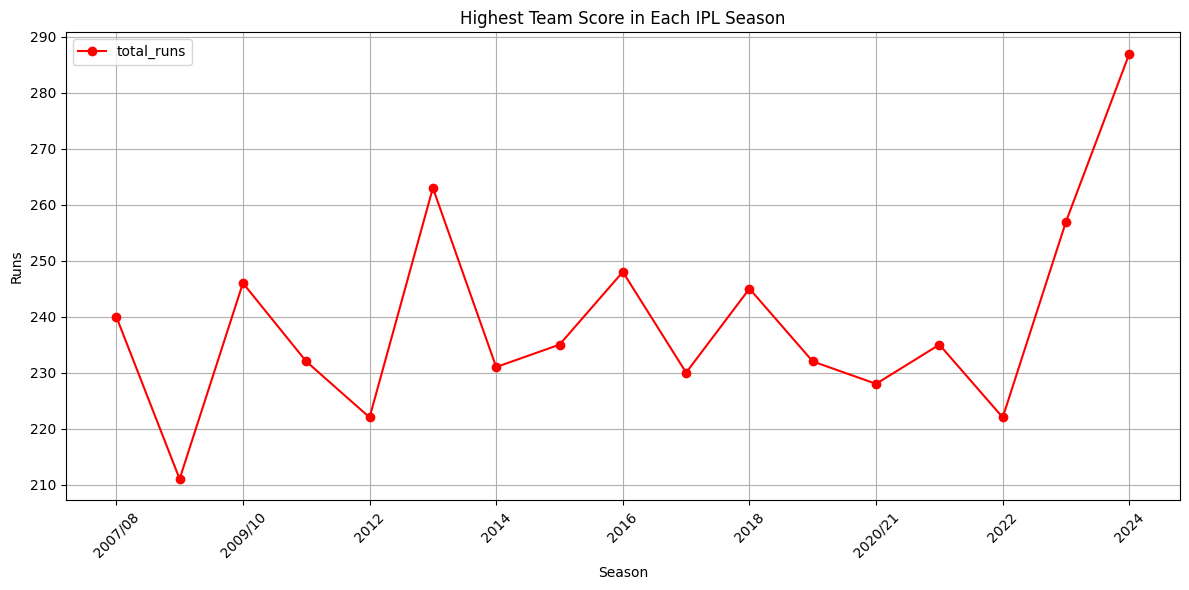

In [264]:
season_highest_team.plot(
    x='season',
    y='total_runs',
    kind='line',
    figsize=(12,6),
    marker ='o',
    color= 'red'

)
plt.title('Highest Team Score in Each IPL Season')
plt.xlabel('Season')
plt.ylabel('Runs')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()

plt.savefig('Images/season_highest_team_score.png',dpi=500,bbox_inches='tight')

plt.show()


## Highest Team Score by Season

This visualization shows the highest team total recorded in each IPL season.

### Key Insight
- Team scores have generally increased over time.
- Recent IPL seasons have witnessed several record-breaking totals.
- The rise in scoring reflects aggressive batting approaches, improved power-hitting, and batting-friendly conditions.

In [265]:
top_10_scores = highest_scores.sort_values(by = 'total_runs',ascending= False).head(10)

top_10_scores

# Create unique labels here
top_10_scores['team_score'] = (
    top_10_scores['batting_team']
    + ' ('
    + top_10_scores['total_runs'].astype(str)
    + ')'
)
top_10_scores

,match_id,inning,batting_team,total_runs,season,team_score
2133,1426268,1,Sunrisers Hyderabad,287,2024,Sunrisers Hyderabad (287)
2089,1422126,1,Sunrisers Hyderabad,277,2024,Sunrisers Hyderabad (277)
2105,1422134,1,Kolkata Knight Riders,272,2024,Kolkata Knight Riders (272)
2143,1426273,1,Sunrisers Hyderabad,266,2024,Sunrisers Hyderabad (266)
709,598027,1,Royal Challengers Bengaluru,263,2013,Royal Challengers Bengaluru (263)
2134,1426268,2,Royal Challengers Bengaluru,262,2024,Royal Challengers Bengaluru (262)
2158,1426280,2,Punjab Kings,262,2024,Punjab Kings (262)
2157,1426280,1,Kolkata Knight Riders,261,2024,Kolkata Knight Riders (261)
2002,1359512,1,Lucknow Super Giants,257,2023,Lucknow Super Giants (257)
2159,1426281,1,Delhi Capitals,257,2024,Delhi Capitals (257)


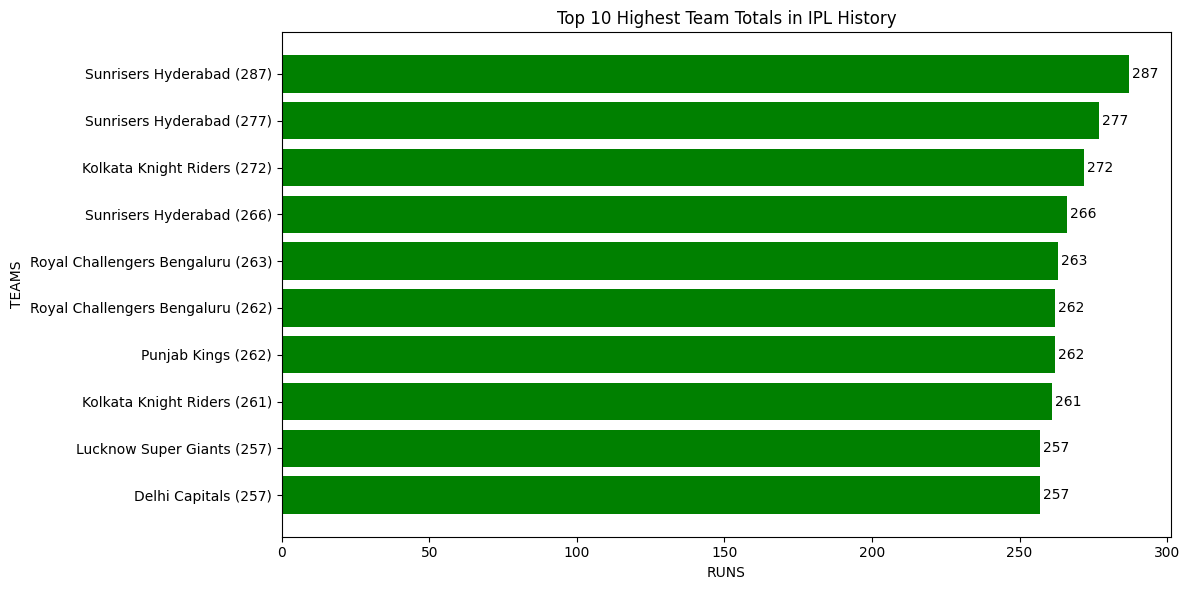

In [266]:
plt.figure(figsize=(12,6))

bars = plt.barh(
    top_10_scores['team_score'],
    top_10_scores['total_runs'],
    color = 'green'
)

plt.title('Top 10 Highest Team Totals in IPL History')
plt.xlabel('RUNS')
plt.ylabel('TEAMS')

for bar in bars:
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        str(int(bar.get_width())),
        va='center'
    )

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    'Images/top_10_highest_team_totals.png',
    dpi=500,
    bbox_inches='tight'
)

plt.show()

### Top 10 Highest Team Totals in IPL History

- Sunrisers Hyderabad recorded the highest team total in IPL history with **287 runs**.
- Sunrisers Hyderabad appears multiple times among the highest IPL totals.
- Kolkata Knight Riders and Royal Challengers Bengaluru also feature prominently in the top-scoring innings list.
- Most of the highest totals have been recorded in recent IPL seasons, indicating the growing dominance of aggressive batting strategies.

In [267]:
team_wins = matches['winner'].value_counts()

team_wins.head(10)

,count
winner,
Mumbai Indians,144
Chennai Super Kings,138
Kolkata Knight Riders,131
Royal Challengers Bengaluru,123
Delhi Capitals,115
Punjab Kings,112
Rajasthan Royals,112
Sunrisers Hyderabad,88
Deccan Chargers,29


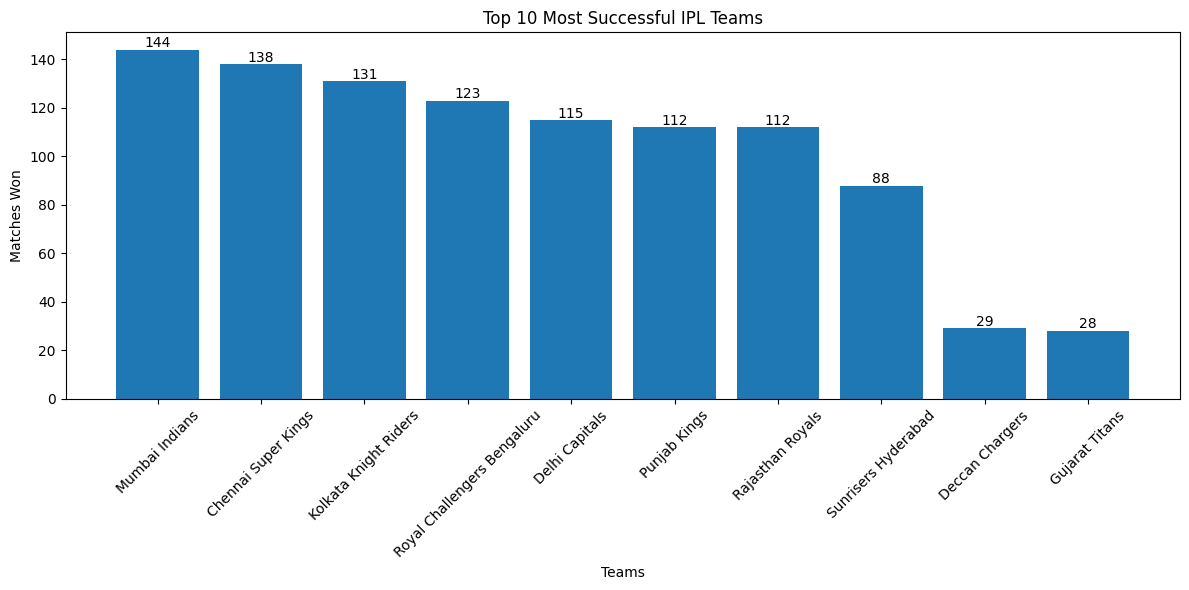

In [268]:
top_10_wins = team_wins.head(10)

plt.figure(figsize=(12,6))

bars = plt.bar(
    top_10_wins.index,
    top_10_wins.values
)

plt.title('Top 10 Most Successful IPL Teams')
plt.xlabel('Teams')
plt.ylabel('Matches Won')

plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        str(int(bar.get_height())),
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    'Images/top_10_team_wins.png',
    dpi=500,
    bbox_inches='tight'
)

plt.show()

### Teams with Most Wins in IPL History

- Mumbai Indians and Chennai Super Kings are among the most successful franchises in IPL history.
- These teams have consistently performed well across multiple seasons.
- Kolkata Knight Riders and Royal Challengers Bengaluru also rank among the top teams by total wins.
- Match wins provide a strong indicator of long-term franchise success and consistency.

In [269]:
top_batsmen=(deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False))

top_batsmen.head(10)






,batsman_runs
batter,
V Kohli,8014
S Dhawan,6769
RG Sharma,6630
DA Warner,6567
SK Raina,5536
MS Dhoni,5243
AB de Villiers,5181
CH Gayle,4997
RV Uthappa,4954


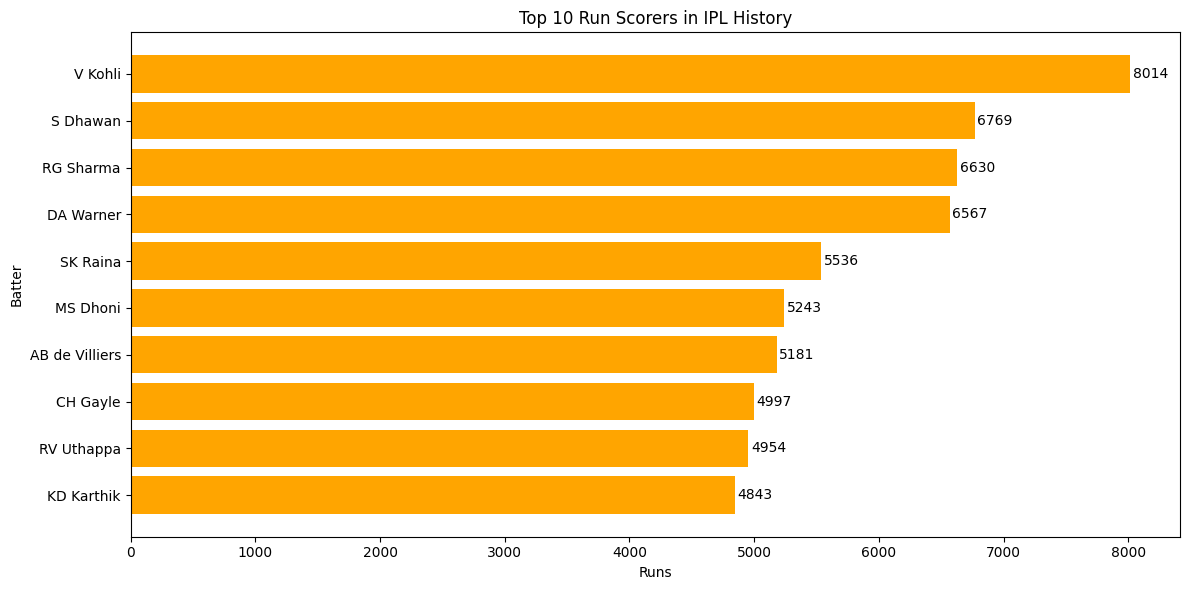

In [270]:
top_10_batsmen = top_batsmen.head(10)

plt.figure(figsize=(12,6))

bars = plt.barh(
    top_10_batsmen.index,
    top_10_batsmen.values,
    color='orange'
)

plt.title('Top 10 Run Scorers in IPL History')
plt.xlabel('Runs')
plt.ylabel('Batter')

for bar in bars:
    plt.text(
        bar.get_width()+20,
        bar.get_y()+bar.get_height()/2,
        str(int(bar.get_width())),
        va='center'
    )

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    'Images/top_10_run_scorers.png',
    dpi=500,
    bbox_inches='tight'
)

plt.show()

### Top Run Scorers in IPL History

- Virat Kohli is among the leading run scorers in IPL history.
- Consistent batting performances over multiple seasons contribute significantly to a player's total runs.
- The top run scorers demonstrate remarkable longevity and consistency in the tournament.
- Run aggregates help identify the most successful batters across IPL seasons.

In [271]:
top_bowlers = (
    deliveries[deliveries['is_wicket'] == 1]
    .groupby('bowler')['is_wicket']
    .count()
    .sort_values(ascending=False)
)

top_bowlers.head(10)

,is_wicket
bowler,
YS Chahal,213
DJ Bravo,207
PP Chawla,201
SP Narine,200
R Ashwin,198
B Kumar,195
SL Malinga,188
A Mishra,183
JJ Bumrah,182


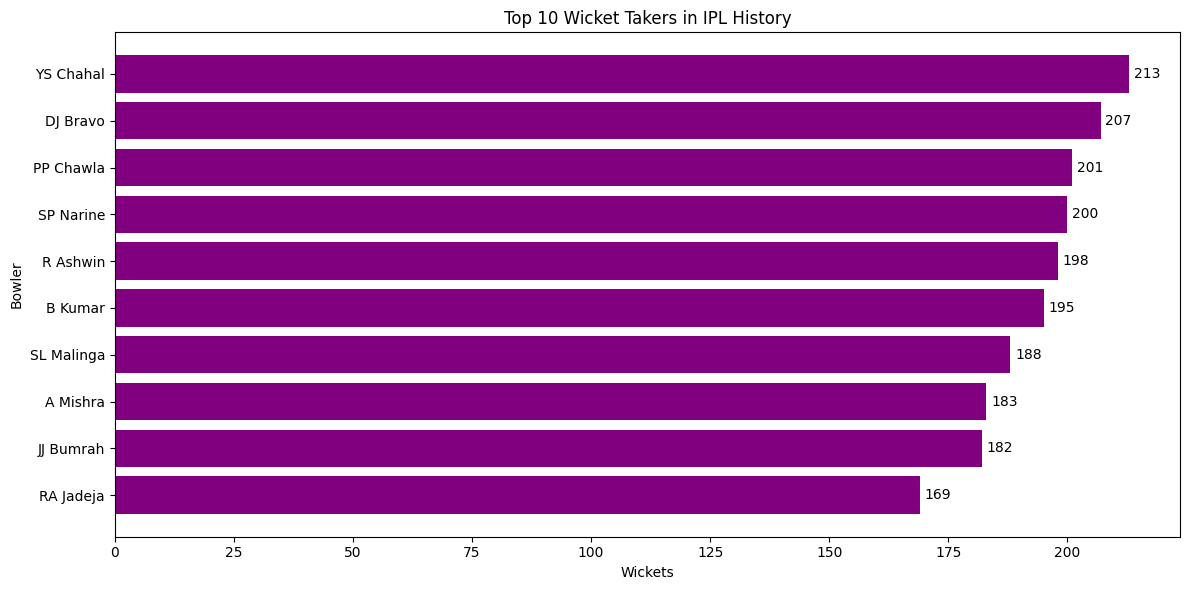

In [272]:
top_10_bowlers = top_bowlers.head(10)

plt.figure(figsize=(12,6))

bars = plt.barh(
    top_10_bowlers.index,
    top_10_bowlers.values,
    color='purple'
)

plt.title('Top 10 Wicket Takers in IPL History')
plt.xlabel('Wickets')
plt.ylabel('Bowler')

for bar in bars:
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        str(int(bar.get_width())),
        va='center'
    )

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    'Images/top_10_wicket_takers.png',
    dpi=500,
    bbox_inches='tight'
)

plt.show()

### Top 10 Wicket Takers in IPL History

- Yuzvendra Chahal is among the leading wicket-takers in IPL history.
- Dwayne Bravo and Piyush Chawla also feature prominently in the top wicket-taking list.
- Consistent wicket-taking ability over multiple seasons is a key indicator of bowling success.
- The top wicket-takers have played crucial roles in restricting opposition scoring and winning matches for their teams.

In [273]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [282]:
individual_scores = (
    deliveries.groupby(['match_id', 'batter'])['batsman_runs']
    .sum()
    .reset_index()
)

top_10_individual = (
    individual_scores
    .sort_values('batsman_runs', ascending=False)
    .head(10)
)

top_10_individual

,match_id,batter,batsman_runs
5302,598027,CH Gayle,175
2,335982,BB McCullum,158
14108,1304112,Q de Kock,140
7528,829795,AB de Villiers,133
11583,1216510,KL Rahul,132
15383,1370352,Shubman Gill,129
8359,980987,AB de Villiers,129
4687,548372,CH Gayle,128
10149,1136602,RR Pant,128
2237,419137,M Vijay,127


In [283]:

top_10_individual = pd.merge(
    top_10_individual,
    matches[['id', 'season']],
    left_on='match_id',
    right_on='id'
)

top_10_individual

top_10_individual['label'] = (
    top_10_individual['batter']
    + ' (' +
    top_10_individual['batsman_runs'].astype(str)
    + ')'
)
top_10_individual


,match_id,batter,batsman_runs,id,season,label
0,598027,CH Gayle,175,598027,2013,CH Gayle (175)
1,335982,BB McCullum,158,335982,2007/08,BB McCullum (158)
2,1304112,Q de Kock,140,1304112,2022,Q de Kock (140)
3,829795,AB de Villiers,133,829795,2015,AB de Villiers (133)
4,1216510,KL Rahul,132,1216510,2020/21,KL Rahul (132)
5,1370352,Shubman Gill,129,1370352,2023,Shubman Gill (129)
6,980987,AB de Villiers,129,980987,2016,AB de Villiers (129)
7,548372,CH Gayle,128,548372,2012,CH Gayle (128)
8,1136602,RR Pant,128,1136602,2018,RR Pant (128)
9,419137,M Vijay,127,419137,2009/10,M Vijay (127)


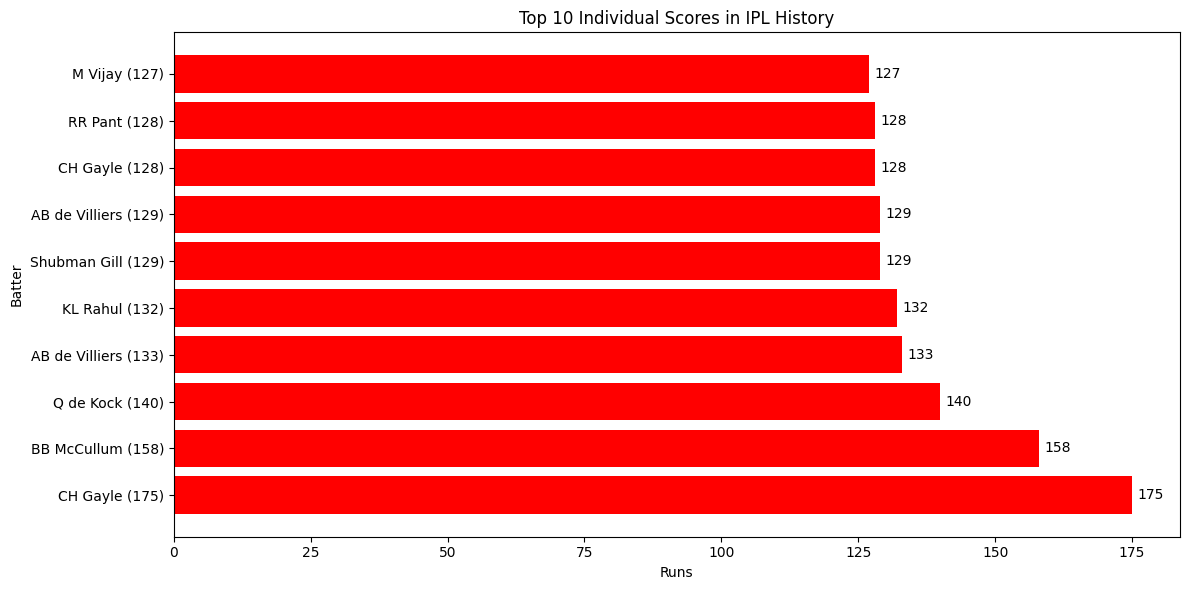

In [313]:
plt.close('all')

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.barh(
    top_10_individual['label'],
    top_10_individual['batsman_runs'],
    color='red'
)

ax.set_title('Top 10 Individual Scores in IPL History')
ax.set_xlabel('Runs')
ax.set_ylabel('Batter')

for bar in bars:
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width())}',
        va='center'
    )

plt.tight_layout()
plt.savefig(
    'Images/Top 10 Individual Scores in IPL History.png',
    dpi=500,
    bbox_inches='tight'
)
plt.show()

- Y-axis = Bowler Name
- X-axis = Total Wickets
- Longer bar = More wickets
- Helps identify the most successful wicket-taking bowlers in IPL history

#  Venue Analysis

Venue conditions can significantly influence match outcomes and scoring patterns.

This section investigates:

- Which venues host the most IPL matches?
- Which venues are the highest-scoring grounds?
- Does venue influence team performance?

In [288]:
venue_counts = matches['venue'].value_counts()

venue_counts.head(10)

,count
venue,
Eden Gardens,77
Wankhede Stadium,73
M Chinnaswamy Stadium,65
Feroz Shah Kotla,60
"Rajiv Gandhi International Stadium, Uppal",49
"MA Chidambaram Stadium, Chepauk",48
Sawai Mansingh Stadium,47
Dubai International Cricket Stadium,46
"Wankhede Stadium, Mumbai",45


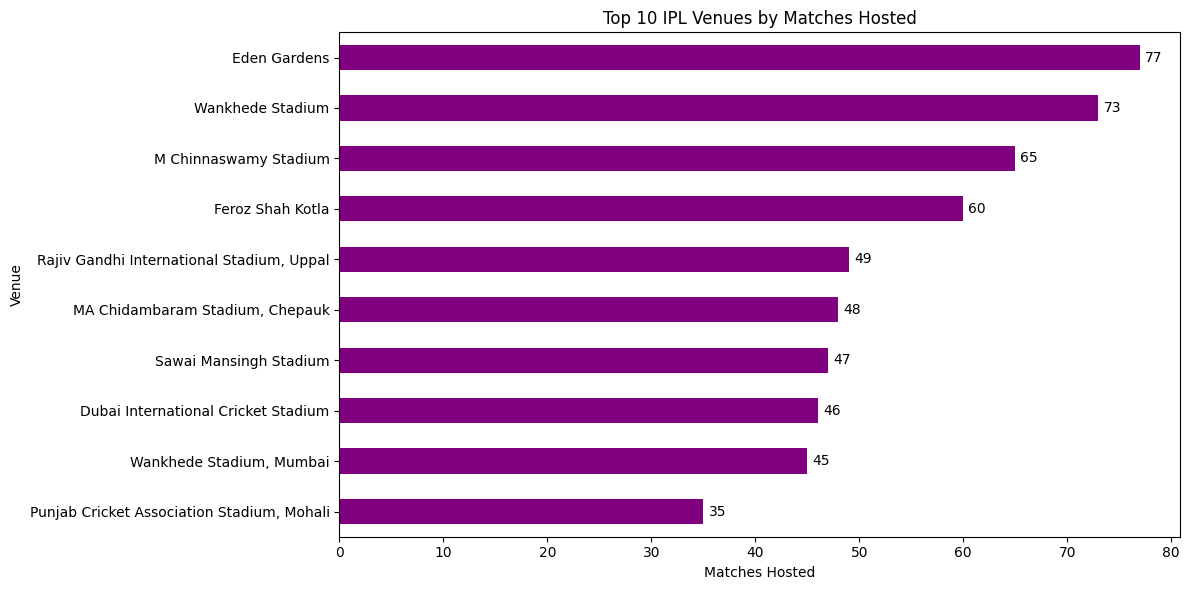

In [289]:
top_venues = venue_counts.head(10)

ax = top_venues.sort_values().plot(
    kind='barh',
    figsize=(12,6),
    color='purple'
)

plt.title('Top 10 IPL Venues by Matches Hosted')
plt.xlabel('Matches Hosted')
plt.ylabel('Venue')

for bar in ax.patches:
    plt.text(
        bar.get_width()+0.5,
        bar.get_y()+bar.get_height()/2,
        str(int(bar.get_width())),
        va='center'
    )

plt.tight_layout()
plt.savefig(
    'Images/top_10_wicket_takers.png',
    dpi=500,
    bbox_inches='tight'
)
plt.show()

### Key Findings

- Eden Gardens hosted the highest number of IPL matches.
- Wankhede Stadium and M Chinnaswamy Stadium are among the most frequently used venues.
- Historic IPL venues continue to dominate match hosting responsibilities.

In [298]:
venue_data = deliveries.merge(
    matches[['id', 'venue']],
    left_on='match_id',
    right_on='id',
    how='left'
)

In [299]:
venue_runs = venue_data.groupby('venue')['total_runs'].sum()

venue_matches = matches['venue'].value_counts()

avg_venue_score = (
    venue_runs / venue_matches
).sort_values(ascending=False)

avg_venue_score.head(10)

,0
venue,
"Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam",400.000000
"Arun Jaitley Stadium, Delhi",380.687500
"Eden Gardens, Kolkata",380.312500
"M Chinnaswamy Stadium, Bengaluru",380.142857
"Himachal Pradesh Cricket Association Stadium, Dharamsala",378.750000
"Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",371.200000
"Rajiv Gandhi International Stadium, Uppal, Hyderabad",364.846154
Brabourne Stadium,348.100000
Punjab Cricket Association IS Bindra Stadium,347.600000


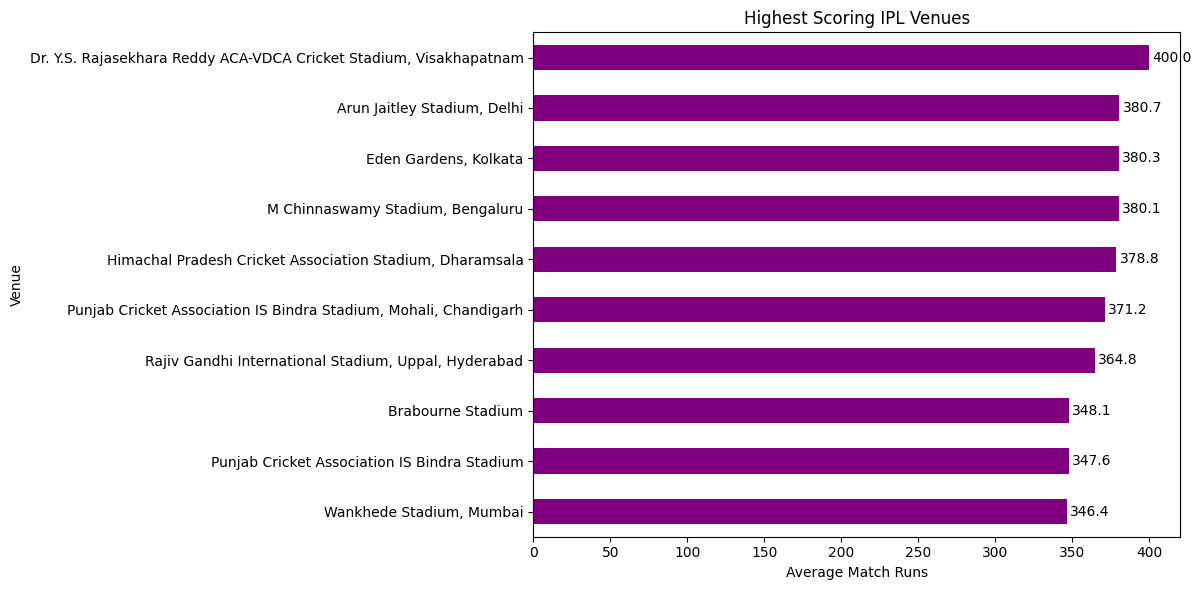

In [315]:
top_10_venues = avg_venue_score.head(10).sort_values()

ax = top_10_venues.plot(
    kind='barh',
    figsize=(12,6),
    color='purple'
)

plt.title('Highest Scoring IPL Venues')
plt.xlabel('Average Match Runs')
plt.ylabel('Venue')

for bar in ax.patches:
    plt.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.1f}',
        va='center'
    )

plt.tight_layout()
plt.savefig(
    'Images/Highest Scoring IPL Venues.png',
    dpi=500,
    bbox_inches='tight'
)
plt.show()

In [301]:
matches.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [302]:
closest_wins = (
    matches[matches['result'] == 'runs']
    .sort_values('result_margin')
)

closest_wins[
    ['season','team1','team2','winner','result_margin']
].head(10)

,season,team1,team2,winner,result_margin
44,2007/08,Mumbai Indians,Punjab Kings,Punjab Kings,1.0
1059,2024,Kolkata Knight Riders,Royal Challengers Bengaluru,Kolkata Knight Riders,1.0
104,2009,Deccan Chargers,Punjab Kings,Punjab Kings,1.0
837,2021,Royal Challengers Bengaluru,Delhi Capitals,Royal Challengers Bengaluru,1.0
755,2019,Mumbai Indians,Chennai Super Kings,Mumbai Indians,1.0
284,2012,Delhi Capitals,Rajasthan Royals,Delhi Capitals,1.0
734,2019,Royal Challengers Bengaluru,Chennai Super Kings,Royal Challengers Bengaluru,1.0
1017,2023,Lucknow Super Giants,Kolkata Knight Riders,Lucknow Super Giants,1.0
290,2012,Pune Warriors,Mumbai Indians,Mumbai Indians,1.0
459,2015,Chennai Super Kings,Delhi Capitals,Chennai Super Kings,1.0


In [304]:
largest_wins = (
    matches[matches['result'] == 'runs']
    .sort_values('result_margin', ascending=False)
)

largest_wins[
    ['season','team1','team2','winner','result_margin']
].head(10)

,season,team1,team2,winner,result_margin
620,2017,Delhi Capitals,Mumbai Indians,Mumbai Indians,146.0
560,2016,Royal Challengers Bengaluru,Gujarat Lions,Royal Challengers Bengaluru,144.0
0,2007/08,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,140.0
496,2015,Royal Challengers Bengaluru,Punjab Kings,Royal Challengers Bengaluru,138.0
352,2013,Royal Challengers Bengaluru,Pune Warriors,Royal Challengers Bengaluru,130.0
706,2019,Sunrisers Hyderabad,Royal Challengers Bengaluru,Sunrisers Hyderabad,118.0
1009,2023,Royal Challengers Bengaluru,Rajasthan Royals,Royal Challengers Bengaluru,112.0
236,2011,Punjab Kings,Royal Challengers Bengaluru,Punjab Kings,111.0
1039,2024,Kolkata Knight Riders,Delhi Capitals,Kolkata Knight Riders,106.0
55,2007/08,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,105.0


In [319]:
super_over_matches = matches[matches['super_over'] == 'Y']

print("Total Super Over Matches:", len(super_over_matches))

super_over_matches[
    ['season','team1','team2','winner']
].head(20)

Total Super Over Matches: 14


,season,team1,team2,winner
66,2009,Kolkata Knight Riders,Rajasthan Royals,Rajasthan Royals
130,2009/10,Chennai Super Kings,Punjab Kings,Punjab Kings
328,2013,Sunrisers Hyderabad,Royal Challengers Bengaluru,Sunrisers Hyderabad
342,2013,Royal Challengers Bengaluru,Delhi Capitals,Royal Challengers Bengaluru
416,2014,Kolkata Knight Riders,Rajasthan Royals,Rajasthan Royals
475,2015,Rajasthan Royals,Punjab Kings,Punjab Kings
610,2017,Gujarat Lions,Mumbai Indians,Mumbai Indians
705,2019,Kolkata Knight Riders,Delhi Capitals,Delhi Capitals
746,2019,Mumbai Indians,Sunrisers Hyderabad,Mumbai Indians
757,2020/21,Delhi Capitals,Punjab Kings,Delhi Capitals


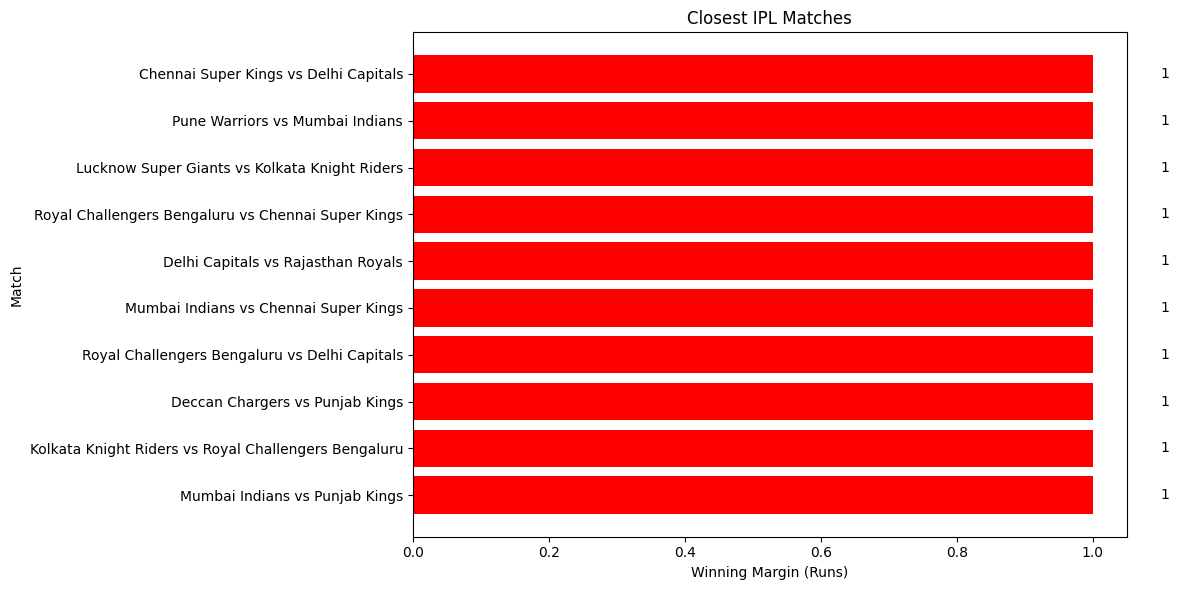

In [316]:
top_closest = (
    closest_wins.head(10)
    .sort_values('result_margin', ascending=False)
)

labels = (
    top_closest['team1']
    + " vs "
    + top_closest['team2']
)

plt.figure(figsize=(12,6))

bars = plt.barh(
    y=labels,
    width=top_closest['result_margin'],
    color='red'
)

plt.title('Closest IPL Matches')
plt.xlabel('Winning Margin (Runs)')
plt.ylabel('Match')

for bar in bars:
    plt.text(
        bar.get_width()+0.1,
        bar.get_y()+bar.get_height()/2,
        str(int(bar.get_width())),
        va='center'
    )

plt.tight_layout()
plt.savefig(
    'Images/closest IPL Matches.png',
    dpi=500,
    bbox_inches='tight'
)
plt.show()

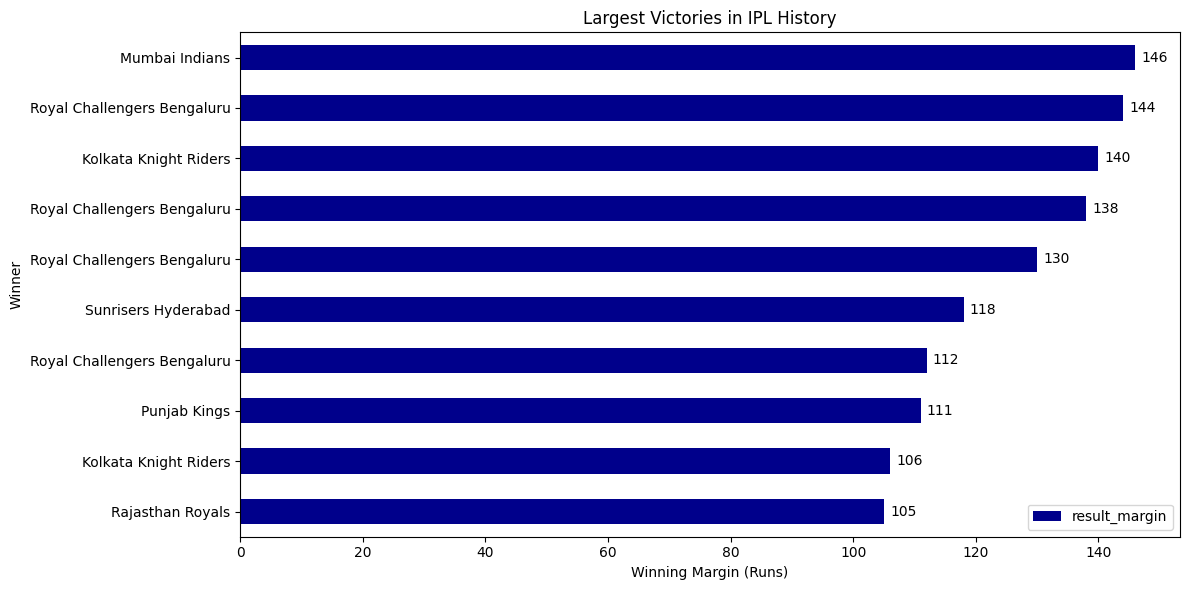

In [317]:
top_large = largest_wins.head(10).sort_values('result_margin')

top_large['winner_label'] = top_large['winner']

ax = top_large.plot(
    x='winner_label',
    y='result_margin',
    kind='barh',
    figsize=(12,6),
    color='darkblue'
)

plt.title('Largest Victories in IPL History')
plt.xlabel('Winning Margin (Runs)')
plt.ylabel('Winner')

for bar in ax.patches:
    plt.text(
        bar.get_width()+1,
        bar.get_y()+bar.get_height()/2,
        str(int(bar.get_width())),
        va='center'
    )

plt.tight_layout()
plt.savefig(
    'Images/Largest Victories in IPL History.png',
    dpi=500,
    bbox_inches='tight'
)
plt.show()

# Final Conclusions

## Key Findings

- Highest Team Total: Sunrisers Hyderabad (287)
- Highest Individual Score: Chris Gayle (175)
- Most Runs: Virat Kohli
- Most Wickets: YS Chahal
- Highest Scoring Venue: Visakhapatnam
- Closest Winning Margin: 1 Run

## Conclusion

IPL success depends on a combination of team quality, player consistency, venue conditions, and match strategy. While factors such as the toss may have some influence, long-term success is primarily driven by strong batting, effective bowling, and consistent team performance.